# H3 Test of Grid Changes
This code aims to test how often an aircraft changes grid during a flight. This information will impact how often the weather data will adjust dynamically.

Flights analyzed: 4609

--- H3 resolution 5 ---
Total trajectory points: 4048210
Total cell changes: 285152
Mean changes per flight: 61.9
Mean dwell time in a cell: 69.9 s (14.0 points)
Median dwell time: 70.0 s
Overall: one cell change every 71.0 s on average

Saved h3_change_analysis.png


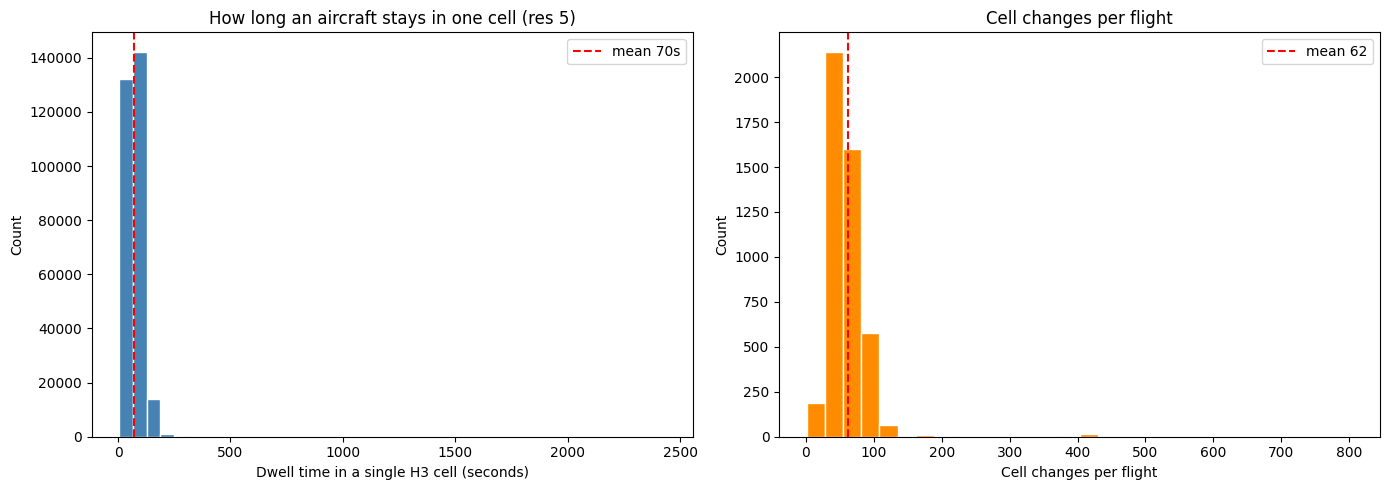

In [1]:
from pathlib import Path
import h3
import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt

DATA_SOURCE = Path("./src/data/raw")
AIRPORT = "LFBO"
H3_RESOLUTION = 5
SAMPLING_SECONDS = 5

def load_flights(data_source, airport):
    lf = pl.scan_parquet(
        source=str(Path(data_source) / "**" / "*.parquet"),
        hive_schema={"destination": pl.String, "year": pl.Int64, "month": pl.Int64, "day": pl.Int64},
        hive_partitioning=True,
        cast_options=pl.ScanCastOptions(datetime_cast="nanosecond-downcast"),
    ).filter(pl.col("destination") == airport)
    return lf.select("flight_id", "latitude", "longitude", "timestamp").collect()

def analyze(df, resolution):
    changes_per_flight = []
    dwell_times = []
    total_points = 0
    total_changes = 0
    for row in df.iter_rows(named=True):
        lats = row["latitude"]; lons = row["longitude"]
        cells = [h3.latlng_to_cell(la, lo, resolution) for la, lo in zip(lats, lons)]
        n = len(cells)
        total_points += n
        if n < 2:
            changes_per_flight.append(0)
            continue
        changes = 0
        run_len = 1
        for i in range(1, n):
            if cells[i] != cells[i-1]:
                changes += 1
                dwell_times.append(run_len)
                run_len = 1
            else:
                run_len += 1
        dwell_times.append(run_len)
        changes_per_flight.append(changes)
        total_changes += changes
    return {
        "changes_per_flight": np.array(changes_per_flight),
        "dwell_points": np.array(dwell_times),
        "total_points": total_points,
        "total_changes": total_changes,
    }

def main():
    df = load_flights(DATA_SOURCE, AIRPORT)
    n_flights = df.height
    print(f"Flights analyzed: {n_flights}")
    res = analyze(df, H3_RESOLUTION)

    dwell_pts = res["dwell_points"]
    dwell_secs = dwell_pts * SAMPLING_SECONDS
    cpf = res["changes_per_flight"]

    print(f"\n--- H3 resolution {H3_RESOLUTION} ---")
    print(f"Total trajectory points: {res['total_points']}")
    print(f"Total cell changes: {res['total_changes']}")
    print(f"Mean changes per flight: {cpf.mean():.1f}")
    print(f"Mean dwell time in a cell: {dwell_secs.mean():.1f} s ({dwell_pts.mean():.1f} points)")
    print(f"Median dwell time: {np.median(dwell_secs):.1f} s")
    if res['total_changes'] > 0:
        overall = res['total_points'] * SAMPLING_SECONDS / res['total_changes']
        print(f"Overall: one cell change every {overall:.1f} s on average")

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].hist(dwell_secs, bins=40, color="steelblue", edgecolor="white")
    axes[0].axvline(dwell_secs.mean(), color="red", linestyle="--", label=f"mean {dwell_secs.mean():.0f}s")
    axes[0].set_xlabel("Dwell time in a single H3 cell (seconds)")
    axes[0].set_ylabel("Count")
    axes[0].set_title(f"How long an aircraft stays in one cell (res {H3_RESOLUTION})")
    axes[0].legend()

    axes[1].hist(cpf, bins=30, color="darkorange", edgecolor="white")
    axes[1].axvline(cpf.mean(), color="red", linestyle="--", label=f"mean {cpf.mean():.0f}")
    axes[1].set_xlabel("Cell changes per flight")
    axes[1].set_ylabel("Count")
    axes[1].set_title("Cell changes per flight")
    axes[1].legend()
    plt.tight_layout()
    plt.savefig("h3_change_analysis.png", dpi=110)
    print("\nSaved h3_change_analysis.png")

if __name__ == "__main__":
    main()